# CoCoLoFa Data Exploration

This notebook explores the preprocessed **CoCoLoFa** (Comments with Common Logical Fallacies) dataset. We analyze the class distribution, comment length characteristics, and common word patterns across different fallacy types.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import Counter
import re

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Preprocessed Data

Load the CSV files generated by `preprocess.py`.

In [2]:
data_dir = "processed"
train_df = pd.read_csv(os.path.join(data_dir, "train_processed.csv"))
dev_df = pd.read_csv(os.path.join(data_dir, "dev_processed.csv"))
test_df = pd.read_csv(os.path.join(data_dir, "test_processed.csv"))

print(f"Train size: {len(train_df)}")
print(f"Dev size:   {len(dev_df)}")
print(f"Test size:  {len(test_df)}")

train_df.head()

Train size: 5370
Dev size:   1538
Test size:  798


,article_id,news_title,news_content,comment_id,parent_comment,comment_text,fallacy,combined_text
0,262,"Even with a law, São Paulo's municipalities ar...",This story was written by Paulo Talarico and P...,5584,NaN,Lack of transparency in government isn't unexp...,none,"Title: Even with a law, São Paulo's municipali..."
1,262,"Even with a law, São Paulo's municipalities ar...",This story was written by Paulo Talarico and P...,5582,NaN,While the issues discussed here should be addr...,appeal to authority,"Title: Even with a law, São Paulo's municipali..."
2,262,"Even with a law, São Paulo's municipalities ar...",This story was written by Paulo Talarico and P...,5583,NaN,The excuse that Brazilian municipalities do no...,none,"Title: Even with a law, São Paulo's municipali..."
3,262,"Even with a law, São Paulo's municipalities ar...",This story was written by Paulo Talarico and P...,6183,NaN,This is what's to be expected of developing an...,none,"Title: Even with a law, São Paulo's municipali..."
4,262,"Even with a law, São Paulo's municipalities ar...",This story was written by Paulo Talarico and P...,6182,Lack of transparency in government isn't unexp...,"Sad to say, I have to agree with you. Rulers c...",appeal to tradition,"Title: Even with a law, São Paulo's municipali..."


## 2. Fallacy Class Distribution

Visualize the balance (or imbalance) of logical fallacies across the training set.

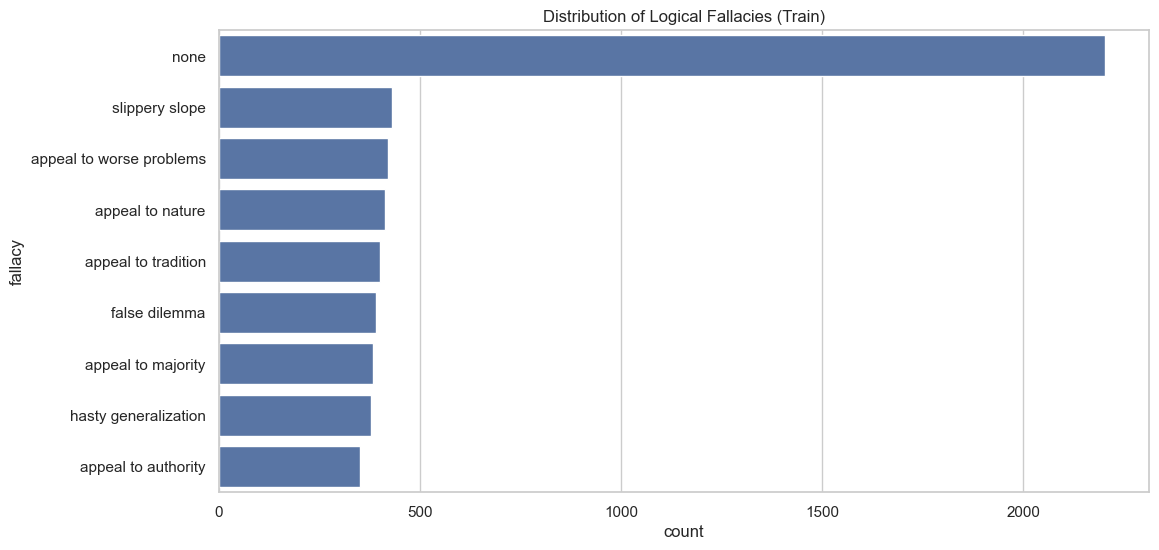

In [3]:
order = train_df['fallacy'].value_counts().index
sns.countplot(data=train_df, y='fallacy', order=order)
plt.title("Distribution of Logical Fallacies (Train)")
plt.show()

## 3. Text Length Analysis

Does the length of a comment correlate with specific fallacy types? For example, are 'none' comments (neutral arguments) typically longer?

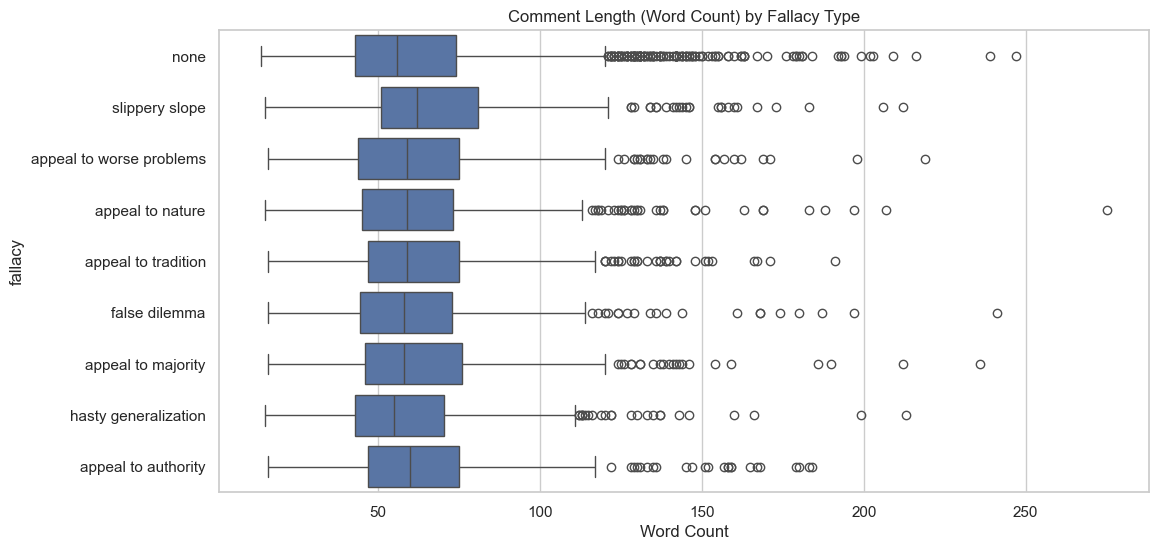

Average Comment Length by Fallacy:
fallacy
slippery slope              68.665893
appeal to authority         65.445714
appeal to tradition         65.102244
appeal to nature            64.531553
appeal to majority          64.503916
appeal to worse problems    63.472684
none                        62.451862
false dilemma               62.130435
hasty generalization        60.535620
Name: comment_len, dtype: float64


In [4]:
train_df['comment_len'] = train_df['comment_text'].str.split().str.len()

sns.boxplot(data=train_df, x='comment_len', y='fallacy', order=order)
plt.title("Comment Length (Word Count) by Fallacy Type")
plt.xlabel("Word Count")
plt.show()

print("Average Comment Length by Fallacy:")
print(train_df.groupby('fallacy')['comment_len'].mean().sort_values(ascending=False))

## 4. Top N-grams per Fallacy

Extract the most common words (excluding stopwords) for each fallacy type to identify potential patterns.

In [5]:
def get_top_words(df, fallacy, n=10):
    text = " ".join(df[df['fallacy'] == fallacy]['comment_text'].values.astype(str)).lower()
    words = re.findall(r'\w+', text)
    # Very basic stopword removal
    stopwords = {'the', 'to', 'and', 'a', 'of', 'in', 'is', 'that', 'it', 'on', 'this', 'be', 'for', 'are', 'with', 'as'}
    filtered_words = [w for w in words if w not in stopwords and len(w) > 2]
    return Counter(filtered_words).most_common(n)

fallacies = train_df['fallacy'].unique()
for f in fallacies:
    top = get_top_words(train_df, f, n=5)
    print(f"[{f.upper()}]: {', '.join([f'{word} ({count})' for word, count in top])}")

[NONE]: they (1566), people (1457), not (1305), can (1001), have (987)
[APPEAL TO AUTHORITY]: they (315), have (207), people (205), their (154), not (151)
[APPEAL TO TRADITION]: they (333), have (276), people (258), not (228), their (208)
[APPEAL TO WORSE PROBLEMS]: more (274), people (254), they (249), not (221), there (210)
[HASTY GENERALIZATION]: they (331), all (197), people (195), not (162), their (156)
[SLIPPERY SLOPE]: will (435), they (414), people (279), not (216), what (205)
[FALSE DILEMMA]: they (427), have (222), can (216), either (212), people (211)
[APPEAL TO MAJORITY]: people (512), majority (314), they (279), should (227), not (203)
[APPEAL TO NATURE]: natural (390), people (385), they (259), not (235), their (224)


## 5. Context Importance

Check how many comments are responses vs. top-level comments.

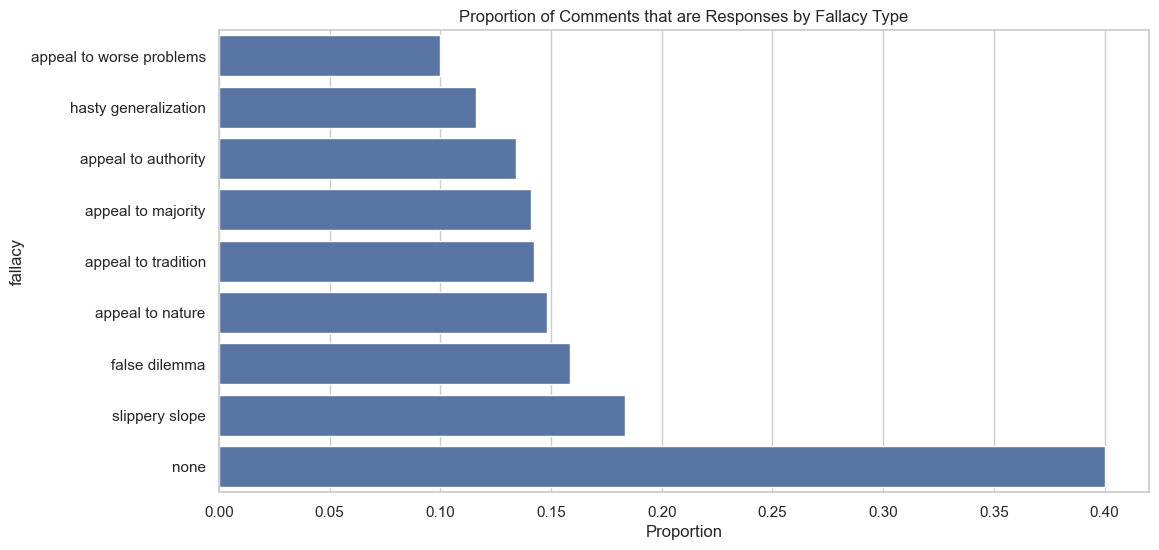

In [6]:
train_df['is_response'] = train_df['parent_comment'].notna() & (train_df['parent_comment'] != "")
res_dist = train_df.groupby('fallacy')['is_response'].mean().sort_values()

sns.barplot(x=res_dist.values, y=res_dist.index)
plt.title("Proportion of Comments that are Responses by Fallacy Type")
plt.xlabel("Proportion")
plt.show()